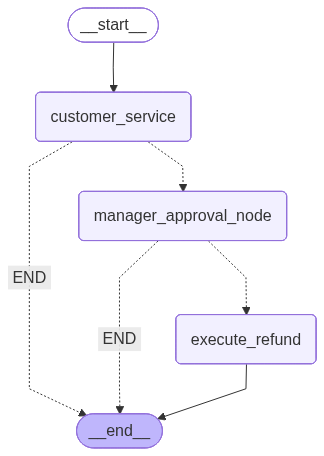

In [32]:
import uuid
from typing import Annotated, Literal
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image, display
# 1. Define State with message history and tracking flags
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    needs_manager_approval: bool
    refund_status: Literal["pending", "approved", "rejected", "none"]

# 2. Define Node Functions
def customer_service_agent(state: AgentState):
    """Initial triage node."""
    last_msg = state["messages"][-1].content.lower() if state["messages"] else ""
    
    if "refund" in last_msg:
        return {
            "messages": [{"role": "assistant", "content": "I see you want a refund. Processing request..."}],
            "needs_manager_approval": True,
            "refund_status": "pending"
        }
    return {
        "messages": [{"role": "assistant", "content": "How can I help you today?"}],
        "needs_manager_approval": False,
        "refund_status": "none"
    }

def manager_approval_node(state: AgentState):
    """An intentional roadblock/human-in-the-loop simulation point."""
    return {
        "messages": [{"role": "assistant", "content": "Manager review required for amounts over $100."}],
    }

def execute_refund(state: AgentState):
    """Final action node execution."""
    status = state.get("refund_status", "pending")
    return {
        "messages": [{"role": "assistant", "content": f"System action completed. Status: {status.upper()}"}]
    }

# 3. Define Conditional Routing Logic
def route_after_agent(state: AgentState) -> Literal["manager_approval_node", "END"]:
    if state.get("needs_manager_approval"):
        return "manager_approval_node"
    return "END"

def route_after_approval(state: AgentState) -> Literal["execute_refund", "END"]:
    # The replay feature will let us manipulate this exact field later
    if state.get("refund_status") == "approved":
        return "execute_refund"
    return "END"

# 4. Compile the Graph with an In-Memory Checkpointer
workflow = StateGraph(AgentState)

workflow.add_node("customer_service", customer_service_agent)
workflow.add_node("manager_approval_node", manager_approval_node)
workflow.add_node("execute_refund", execute_refund)

workflow.add_edge(START, "customer_service")
workflow.add_conditional_edges("customer_service", route_after_agent, {"manager_approval_node": "manager_approval_node", "END": END})
workflow.add_conditional_edges("manager_approval_node", route_after_approval, {"execute_refund": "execute_refund", "END": END})
workflow.add_edge("execute_refund",END)

# MemorySaver is mandatory for capturing state history and replaying
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)
display(Image(app.get_graph().draw_mermaid_png()))

In [33]:
# Create a unique thread ID to isolate this session
config = {"configurable": {"thread_id": str(uuid.uuid4())}}

print("--- -----------------------------------------------------STEP 1: INITIAL RUN ----------------------------------------------")
initial_input = {"messages": [{"role": "user", "content": "I need a refund for my $500 order."}]}
for event in app.stream(initial_input, config, version="v2", stream_mode="values"):
    for message in event['data']['messages']:
        print(message)
    print("="*50)

print("\n--- STEP 2: INSPECT CHECKPOINT HISTORY ---")
# Retrieve the state history list to find past configurations
history = list(app.get_state_history(config))
for state_snapshot in history:
    print(f"Thread ID: {state_snapshot.config['configurable']['thread_id']}")
    print(f"Checkpoint NS: {state_snapshot.config['configurable']['checkpoint_ns']}")
    print(f"Checkpoint ID: {state_snapshot.config['configurable']['checkpoint_id']}")
    print(f"Next Node in queue: {state_snapshot.next}")
    print(f"needs_manager_approval: {state_snapshot.values.get('needs_manager_approval')}")
    print(f"Refund Status: {state_snapshot.values.get('refund_status')}")
    print(f"Messages: {state_snapshot.values['messages']}\n{'-'*150}")

# Find the checkpoint created right after the customer service triage
target_checkpoint = history[2].config["configurable"]["checkpoint_id"]  # This is the checkpoint right after "customer_service" node execution

print(f"--- STEP 3: REPLAYING AND FORKING FROM CHECKPOINT {target_checkpoint} ---")
# Configure the specific point in time we want to jump back to
# include checkpoint_ns so update_state can locate the exact checkpoint namespace
replay_config = {
    "configurable": {
        "thread_id": config["configurable"]["thread_id"],
        "checkpoint_id": target_checkpoint,
        "checkpoint_ns": history[-1].config["configurable"].get("checkpoint_ns", ())
    }
}

# Update the state values *at that specific moment in time* to simulate manager intervention
app.update_state(
    replay_config,
    {"refund_status": "approved"}, # Override the status value
    as_node="manager_approval_node" # Identify who is committing the override
)

print("\n--- STEP 4: RESUMING GRAPH EXECUTION PATH ---")
# Resume streaming. LangGraph picks up from the forked checkpoint
for event in app.stream(None, config, version="v2", stream_mode="values"):
    for message in event['data']['messages']:
        print(message)
    print("="*50)


--- -----------------------------------------------------STEP 1: INITIAL RUN ----------------------------------------------
content='I need a refund for my $500 order.' additional_kwargs={} response_metadata={} id='feab4a71-374e-4175-8b1c-a9c3d383d7c5'
content='I need a refund for my $500 order.' additional_kwargs={} response_metadata={} id='feab4a71-374e-4175-8b1c-a9c3d383d7c5'
content='I see you want a refund. Processing request...' additional_kwargs={} response_metadata={} id='022ad690-cf93-4e59-872e-85c38112415f' tool_calls=[] invalid_tool_calls=[]
content='I need a refund for my $500 order.' additional_kwargs={} response_metadata={} id='feab4a71-374e-4175-8b1c-a9c3d383d7c5'
content='I see you want a refund. Processing request...' additional_kwargs={} response_metadata={} id='022ad690-cf93-4e59-872e-85c38112415f' tool_calls=[] invalid_tool_calls=[]
content='Manager review required for amounts over $100.' additional_kwargs={} response_metadata={} id='57c42d7e-cc45-4c01-88ac-5a7da62a